# imports 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression,LogisticRegression
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error

# Question 1

In [2]:
# 1 =>regression
# 2 => classification
# 3 => unsupervised learning
# 4 => RL


# 2 => final score
# 3 => passed



# Question 2

In [3]:
# جمع اوری داده
# پاکسازی داده 
# مهندسی  ویژگی
#  تقسیم داده به Training و Test
# آموزش مدل 
#  ارزیابی مدل
# استقرار مدل 

# 1 => داده پاکسازی نشده در صورت ورود به یک الگوریتم خوب هم نتیجه بدی دارند
# garbage in garbage out
# 2 => test set is used for evaluation of model.
# 3 => change hyper paremater- add more date - change model algorythms
# 4 => evaluation is the last part of machine learning project.


# Question 3

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          100 non-null    str    
 1   StudyHours         100 non-null    float64
 2   AttendancePercent  100 non-null    float64
 3   PracticeTests      100 non-null    int64  
 4   PreviousScore      100 non-null    float64
 5   FinalScore         100 non-null    float64
 6   Passed             100 non-null    str    
dtypes: float64(4), int64(1), str(2)
memory usage: 5.6 KB


,StudyHours,AttendancePercent,PracticeTests,PreviousScore,FinalScore
StudyHours,1.000000,-0.168548,0.048667,-0.100100,0.431047
AttendancePercent,-0.168548,1.000000,-0.053720,0.092275,0.179831
PracticeTests,0.048667,-0.053720,1.000000,-0.134226,0.201933
PreviousScore,-0.100100,0.092275,-0.134226,1.000000,0.406357
FinalScore,0.431047,0.179831,0.201933,0.406357,1.000000


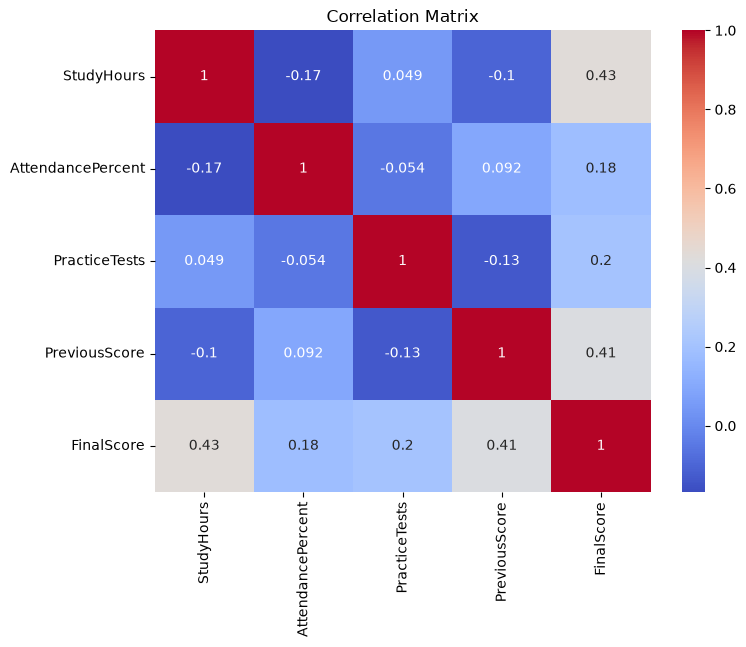

,FinalScore
FinalScore,1.000000
StudyHours,0.431047
PreviousScore,0.406357
PracticeTests,0.201933
AttendancePercent,0.179831


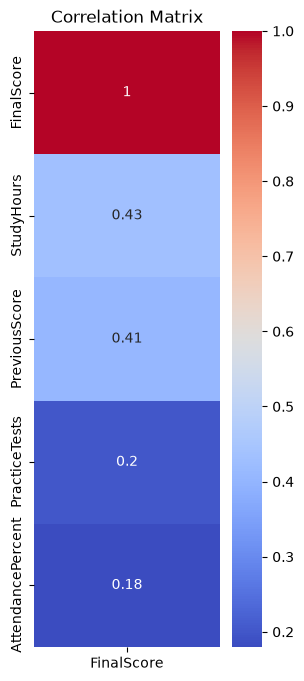

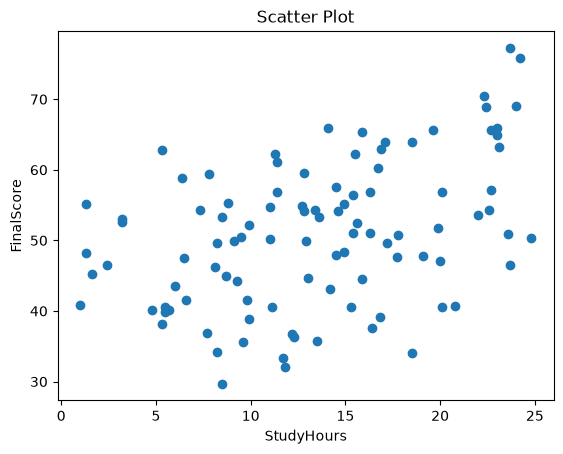

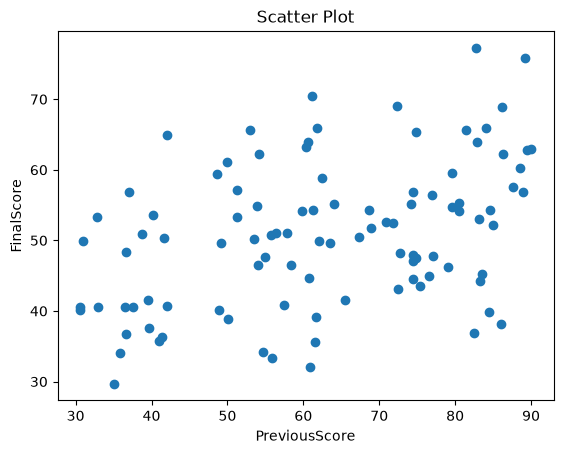

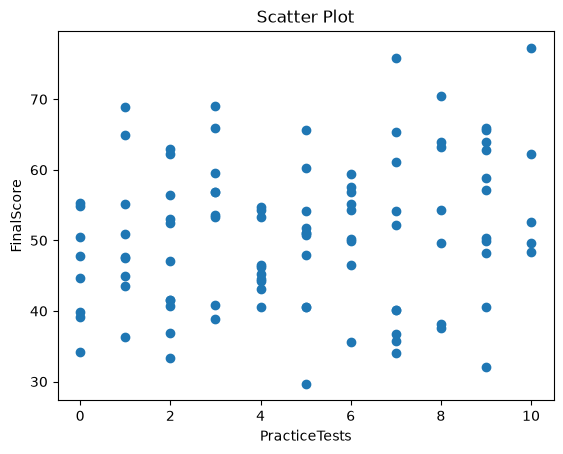

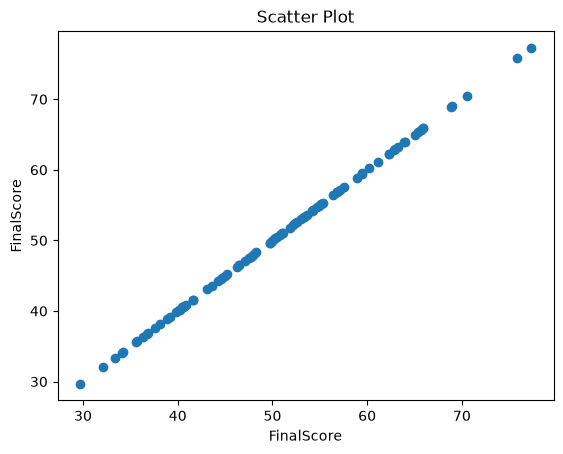

In [18]:


df = pd.read_csv(r"E:\Maktab-145\Datasets\student_performance_session2.csv")

df.head(5)

df.info()

target_column = df["FinalScore"]

numeric_columns = df.iloc[:, 1:-1]
numeric_columns

correlation = numeric_columns.corr()
display(correlation)
plt.figure(figsize=(8,6))

sns.heatmap(correlation,cmap='coolwarm',annot=True)


plt.title("Correlation Matrix")

plt.show()

correlation = df.corr(numeric_only=True)["FinalScore"].sort_values(ascending=False).to_frame()
display(correlation)

plt.figure(figsize=(3,8))

sns.heatmap(correlation,cmap='coolwarm',annot=True)


plt.title("Correlation Matrix")

plt.show()

# sns.pairplot(numeric_columns)
plt.scatter(df["StudyHours"], df["FinalScore"])
plt.xlabel("StudyHours")
plt.ylabel("FinalScore")
plt.title("Scatter Plot")
plt.show()

plt.scatter(df["PreviousScore"], df["FinalScore"])
plt.xlabel("PreviousScore")
plt.ylabel("FinalScore")
plt.title("Scatter Plot")
plt.show()

plt.scatter(df["PracticeTests"], df["FinalScore"])
plt.xlabel("PracticeTests")
plt.ylabel("FinalScore")
plt.title("Scatter Plot")
plt.show()

plt.scatter(df["FinalScore"], df["FinalScore"])
plt.xlabel("FinalScore")
plt.ylabel("FinalScore")
plt.title("Scatter Plot")
plt.show()

# بیشترین همبستگی باStudyHour است، کاملا منطقی است و نشان دهنده نمره بالا در صورت مطالعه بیشتر است
# همبستگی با PreviousScore هم تفریبا مناسب است، چرا که وقتی در آزمون قبلی به طور مثال نمره بالایی کسب شده باشد، در این آزمون هم معمولا نمره مشابه خواهد بود
# هرچه دانش آموز تعداد تست‌های بیشتری تمرین کرده باشد، نمره آن بالاتر خواهد رفت، میزان همبسنگی منطقیست


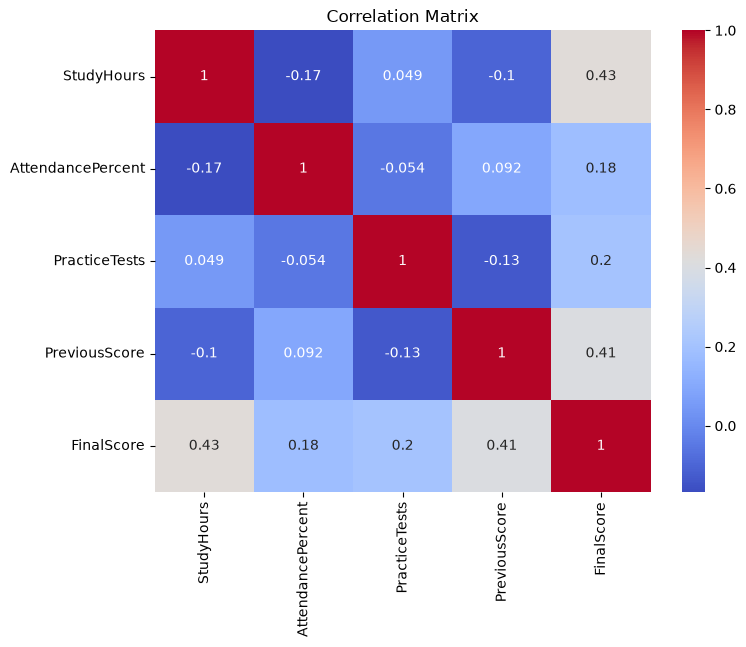

In [16]:
numeric_df = df.iloc[:,1:-1]

corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr,cmap='coolwarm',annot=True)

plt.title("Correlation Matrix")

plt.show()

# Question 4

In [13]:
x = df["StudyHours"].to_frame()
y = df["FinalScore"].to_frame()

Xtrain,Xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

print(Xtrain.shape,Xtest.shape,ytrain.shape,ytest.shape,sep="\n")
# 80 percent of dataset used for training
# 20 percent of dataset used for testing the model 
# we'll use train data for learning
# random state  برای تکرار پذیر کردن نتیجه آزمایش و تغییر نکردن سمپل ها هست 


(80, 1)
(20, 1)
(80, 1)
(20, 1)


#Question 5

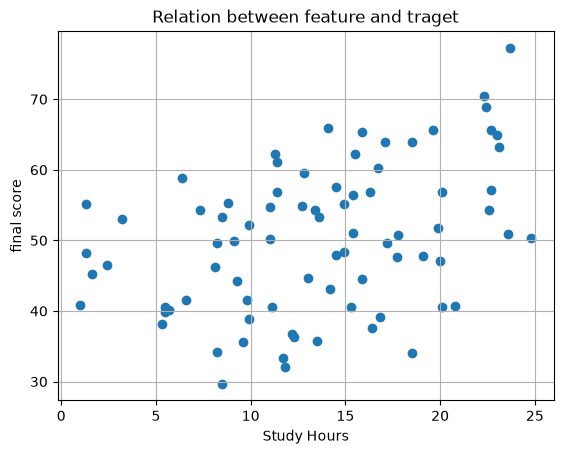

In [19]:
plt.scatter(Xtrain,ytrain)
plt.ylabel('final score')
plt.xlabel("Study Hours")
plt.title("Relation between feature and traget")
plt.grid()
plt.show()

# each point == one sample 

# Question 6

In [20]:



x=df[['StudyHours']]
y=df[['FinalScore']]

Xtrain,Xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)

model=LinearRegression()
model.fit(Xtrain,ytrain)


y_pred = model.predict(Xtest)
print(y_pred)
print (ytest)

print(model.coef_)
print(model.intercept_)

[[43.11813455]
 [49.79041053]
 [50.95977849]
 [49.72162418]
 [45.38808411]
 [46.90138382]
 [52.54186455]
 [46.28230667]
 [57.56326812]
 [44.56264791]
 [46.21352032]
 [45.04415236]
 [57.42569542]
 [51.64764199]
 [56.73783191]
 [47.45167462]
 [44.21871616]
 [57.21933637]
 [52.12914644]
 [56.04996841]]
    FinalScore
83        52.6
53        49.9
70        54.2
45        54.2
44        47.5
39        45.0
22        62.9
80        59.4
10        75.8
0         62.8
18        36.9
30        43.6
73        69.0
33        52.4
90        65.9
4         50.5
76        40.1
77        46.5
12        51.1
31        53.6
[[0.6878635]]
[40.91697134]


# Question 7

In [21]:
mae = np.mean(np.abs(ytest - y_pred))
print(mae)
from sklearn.metrics import mean_absolute_error
mae1 = mean_absolute_error(ytest,y_pred)
print(mae1)

eror = ytest - y_pred
mse = np.mean(eror ** 2)
print(mse)
from sklearn.metrics import mean_squared_error
mse1 = mean_squared_error(ytest,y_pred)
print(mse1)

rmse = np.sqrt(mse)
print(rmse)
from sklearn.metrics import root_mean_squared_error
rmse1 = root_mean_squared_error(ytest,y_pred)
print(rmse1)

r2 = 1 - (np.sum(eror ** 2) / np.sum((ytest - np.mean(ytest)) ** 2))
print(r2)
from sklearn.metrics import r2_score
r2_1 = r2_score(ytest,y_pred)
print(r2_1)

6.744263041078073
6.744263041078073
76.4308633145087
76.4308633145087
8.742474667650384
8.742474667650384
0.16982057264670924
0.16982057264670924


# Question 8

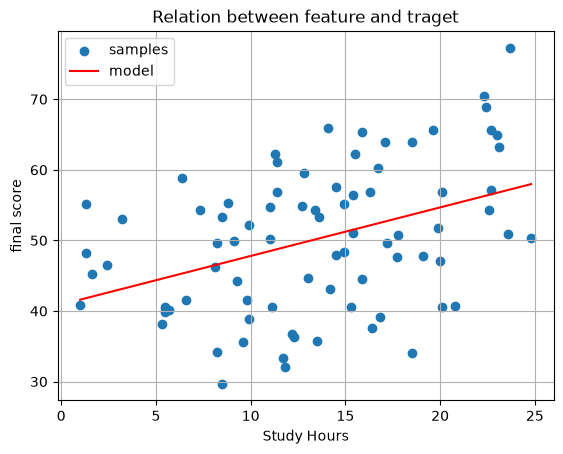

In [22]:

x_range=np.linspace(Xtrain.min(),Xtrain.max(),200)
y_model=x_range@model.coef_+model.intercept_
plt.scatter(Xtrain,ytrain,label="samples")
plt.ylabel('final score')
plt.xlabel("Study Hours")
plt.title("Relation between feature and traget")
plt.grid()
plt.plot(x_range,y_model,c='red',label="model")
plt.legend()
plt.show()

# نقاط samples را نشان میدهد
#پیش بینی مدل رگرسیون
#خطای مدل
#خطای بزرگتری دارد
#خیر
#روند کلی داده


# Question 9

In [23]:
# KNN regressor

student1 =48
student2 =54
student3 =57


model_predict = (student1+student2+student3) / 3

print(f"model predict for new student: {model_predict}")
# nearset sample in feature space is nearest neighbor
# Less distance == more similarty
# K == number of neighbors
# KNN does not learn anything just measure distance between new sample and train set
# KNN save train set datas only 


model predict for new student: 53.0


# Question 10 

r2 metric: 
0.18617392193496574
0.16982057264670924
MAE  metric: 
6.863333333333335
6.744263041078073
MSE  metric: 
74.92528444444446
76.4308633145087
RMSE  metric: 
8.655939258361537
8.742474667650384
6.744263041078073
76.4308633145087
8.742474667650384
0.16982057264670924


e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


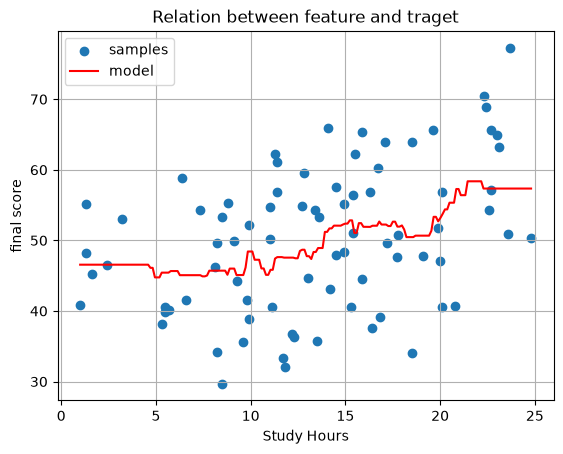

In [24]:
knn_reg = KNeighborsRegressor(n_neighbors=15)
knn_reg.fit(Xtrain,ytrain)



ypred = knn_reg.predict(Xtest)

# measure metrics
r2 = r2_score(ytest,ypred)
mae = mean_absolute_error(ytest,ypred)
mse = mean_squared_error(ytest,ypred)
rmse = root_mean_squared_error(ytest,ypred)


print(f"r2 metric: \n{r2}\n{r2_1}")
print(f"MAE  metric: \n{mae}\n{mae1}")
print(f"MSE  metric: \n{mse}\n{mse1}")
print(f"RMSE  metric: \n{rmse}\n{rmse1}")




print(mae1)
print(mse1)
print(rmse1)
print(r2_1)
x_range=np.linspace(Xtrain.min(),Xtrain.max(),200)
y_model_knn=knn_reg.predict(x_range)
plt.scatter(Xtrain,ytrain,label="samples")
plt.ylabel('final score')
plt.xlabel("Study Hours")
plt.title("Relation between feature and traget")
plt.grid()
plt.plot(x_range,y_model_knn,c='red',label="model")
plt.legend()
plt.show()

# 20 neighbor has smallest MAE = 6.847999999999997
# 10 R2 SCORE was 0.1787222626071282
# 


# Question 11

In [60]:
x = df["StudyHours"].to_frame()
y = np.where(df["Passed"]=="Yes",1,0).reshape(-1,1)
Xtrain,Xtest,ytrain,ytest = train_test_split(x,y,test_size=0.2,random_state=42)
log_reg = LogisticRegression()
log_reg.fit(Xtrain,ytrain)

prob_c = log_reg.predict_proba(Xtest)
ypred = log_reg.predict(Xtest)

# این مسئله کلاس بندی است چرا که داریم کلاس 1 و 0 رو پیش بینی میکنیم 
# خروجی پردیکت نشان دهنده کلاسی است که مدل تشخیص داده داده تست به آن تعلق دارد 
# دو ستون احتمال تعلق استخراج شده از مدل نشان دهنده به ترتیب احتمال تعلق به کلاس 0 و 1 است 
# کلاس 1 خواهد بود 
# در آن صورت کلاس 0 خواهد بود 
# چون رگرسیون خطی یک مقدار پیوسته پیشبینی میکند نه احتمال تعلق 
# چون تابع لوجستیک روی آن اعمال میشود و بعد در آخر ترشهولد آن را به کلاس تبدیل میکند پس رگرسیون نیست کلاس بندی است

e:\Maktab-145\maktab_kernel\Lib\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
